In [1]:
#sys.path.insert(1, os.getcwd())
import os, sys, time
from copy import deepcopy as dcopy
import numpy as np
#import pandas as pd
import camb
from   camb import model, initialpower
import json
import argparse
import warnings
warnings.filterwarnings("ignore")	
path = '/data/AMARINS/LSSxHI-CODES/scripts/'
sys.path.insert(1, path)
import cross_functions_theory as cxft
import handling_data  as hdata
#####################################################################################################
# Check the python version and import configparser
#####################################################################################################
if sys.version_info[0]==2:
	import ConfigParser
	config = ConfigParser.RawConfigParser()
elif sys.version_info[0]==3:
	import configparser
	config = configparser.ConfigParser()

In [2]:
###################################################################
# This part is for extracting information from parameters.ini file
###################################################################
timei       = time.time()
INI         = "generating_APS_theory.ini"
name_params = os.path.join('/data/AMARINS/LSSxHI-CODES/scripts/',INI)
config.read(name_params)
#General
verbose   = config.getboolean("General","verbose")
threshold = config.getfloat(  "General","threshold")
#Cosmology
ombh2   = config.getfloat("Cosmology","ombh2")
omch2   = config.getfloat("Cosmology","omch2")
H0      = config.getfloat("Cosmology","H0")
ns      = config.getfloat("Cosmology","ns")
#CAMB
zmin_integration_camb   = config.getfloat(  "CAMB","zmin_integration_camb"  )
zmax_integration_camb   = config.getfloat(  "CAMB","zmax_integration_camb"  )
zsteps_integration_camb = config.getint(    "CAMB","zsteps_integration_camb")
kmax                    = config.getfloat(  "CAMB","kmax"                   )
minkh                   = config.getfloat(  "CAMB","minkh"                  )
maxkh                   = config.getfloat(  "CAMB","maxkh"                  )
npoints                 = config.getint(    "CAMB","npoints"                )
Pk_nonlinear            = config.getboolean("CAMB","Pk_nonlinear"           )
halofit_version         = config.get(       "CAMB","halofit_version"        )
#load_Pk                = config.getboolean("CAMB","load_Pk"               )
#path_to_Pk             = config.get(       "CAMB","path_to_Pk"            )
#path_to_hubble_z       = config.get(       "CAMB","path_to_hubble_z"      )
#path_to_comovel_dist_z = config.get(       "CAMB","path_to_comovel_dist_z")
############
#APS
field_1             = config.get(        "APS","field_1"            )
field_2             = config.get(        "APS","field_2"            )
l_min               = config.getint(     "APS","l_min"              )
l_max               = config.getint(     "APS","l_max"              )
generate_cl_field_1 = config.getboolean( "APS","generate_cl_field_1")
generate_cl_field_2 = config.getboolean( "APS","generate_cl_field_2")
generate_cl_cross   = config.getboolean( "APS","generate_cl_cross"  )
pathout             = config.get(        "APS","pathout"            )
prefix              = config.get(        "APS","prefix"             )
suffix              = config.get(        "APS","suffix"             )
############
#SHEAR-survey
path_to_shear_params_file = config.get(        "SHEAR","path_to_shear_params_file")
survey_shear              = config.get(        "SHEAR","survey_shear"             )
dataset_shear             = config.get(        "SHEAR","dataset_shear"            )
binning_shear             = config.getboolean( "SHEAR","binning_shear"            )
parameters_shear_set      = config.get(        "SHEAR","parameters_shear_set"     )
photometric_shear_lkl     = config.get(        "SHEAR","photometric_shear_lkl"    )
bin_to_use_shear          = config.getint(     "SHEAR","bin_to_use_shear"         )
include_ia                = config.getboolean( "SHEAR","include_ia"               )
L_model                   = config.get(        "SHEAR","L_model"                  )
L_value                   = config.getfloat(   "SHEAR","L_value"                  )
path_to_L_file            = config.get(        "SHEAR","path_to_L_file"           )
F_model                   = config.get(        "SHEAR","F_model"                  )
F_value                   = config.getfloat(   "SHEAR","F_value"                  )
path_to_F_file            = config.get(        "SHEAR","path_to_F_file"           )
beta_IA                   = config.getfloat(   "SHEAR","beta_IA"                  )
eta_IA                    = config.getfloat(   "SHEAR","eta_IA"                   )
#z_shear_min     = config.getfloat(   "SHEAR","z_shear_min" )
#z_shear_max     = config.getfloat(   "SHEAR","z_shear_max" )

############
#COUNT-survey
path_to_count_params_file = config.get(        "COUNT","path_to_count_params_file")
survey_count              = config.get(        "COUNT","survey_count"             )
dataset_count             = config.get(        "COUNT","dataset_count"            )
mode_count                = config.get(        "COUNT","mode_count"               )
bias_model                = config.get(        "COUNT","bias_model"               )
bias_value                = config.getfloat(   "COUNT","bias_value"               )
path_to_bias_file         = config.get(        "COUNT","path_to_bias_file"        )
binning_count             = config.getboolean( "COUNT","binning_count"            )
parameters_count_set      = config.get(        "COUNT","parameters_count_set"     )
photometric_count_lkl     = config.get(        "COUNT","photometric_count_lkl"    )
bin_to_use_count          = config.getint(     "COUNT","bin_to_use_count"         )
include_rsd               = config.getboolean( "COUNT","include_rsd"              )
include_mb                = config.getboolean( "COUNT","include_mb"               )
mu_rsd                    = config.getfloat(   "COUNT","mu_rsd"                   )
slope_s_model             = config.get(        "COUNT","slope_s_model"            )
slope_s_value             = config.getfloat(   "COUNT","slope_s_value"            )
path_to_slope_s_file      = config.get(        "COUNT","path_to_slope_s_file"     )

############
#HI-survey
#binning_used       = config.get("survey","binning_used")
freq_min        = config.getfloat("HI","freq_min")
freq_max        = config.getfloat("HI","freq_max")
nchannels       = config.getint(  "HI","nchannels")
#window_function_HI = config.get(     "HI","window_function_HI")
#21cm
omegaHI_model = config.get(       "21cm", "OmegaHI_model")
biasHI_model  = config.get(       "21cm", "biasHI_model" )
fit_omegaHI   = config.getboolean("21cm", "fit_omegaHI"  )
fit_biasHI    = config.getboolean("21cm", "fit_biasHI"   )
fit_omegaHI   = False
fit_biasHI    = False
omegaHI       = config.get("21cm","omegaHI")
biasHI        = config.get("21cm","biasHI" )
############
#Figures
save_clplot_field1  = config.get("Figures","save_clplot_field1")
save_clplot_field2  = config.get("Figures","save_clplot_field2")
save_clplot_cross   = config.get("Figures","save_clplot_cross" )
save_cls_together   = config.get("Figures","save_cls_together" )


if omegaHI_model=="":
    omegaHI_model=None
if biasHI_model=="":
    biasHI_model=None
    
if omegaHI=="":
    omegaHI=None
if biasHI=="":
    biasHI=None
    
if prefix=="":
    prefix=None
if suffix=="":
    suffix=None
#print(suffix, type(suffix), len(suffix))
#####################################################################################################################################################################
#####################################################################################################################################################################
params_general = {'verbose'  :verbose,
                  'threshold':threshold}
params = { 'H0'     : H0,
           'ombh2'  : ombh2,
           'omch2'  : omch2,
           'ns'     : ns,
           'z'      : np.logspace(np.log10(zmin_integration_camb),np.log10(zmax_integration_camb), zsteps_integration_camb),
           'kmax'   : kmax,
           'minkh'  : minkh,
           'maxkh'  : maxkh,
           'npoints': npoints,
           'Pk_nonlinear'   : Pk_nonlinear,
           'halofit_version': halofit_version,
           'omegaHI_model'  : omegaHI_model,
           'biasHI_model'   : biasHI_model,
           #'load_Pk'               : load_Pk,
           #'path_to_Pk'            : path_to_Pk,
           #'path_to_hubble_z'      : path_to_hubble_z,
           #'path_to_comovel_dist_z': path_to_comovel_dist_z,
        }          

params_APS    = {'field_1'            :field_1, 
                 'field_2'            :field_2, 
                 'l_min'              :l_min, 
                 'l_max'              :l_max, 
                 'generate_cl_field_1':generate_cl_field_1, 
                 'generate_cl_field_2':generate_cl_field_2, 
                 'generate_cl_cross'  :generate_cl_cross, 
                 'pathout'            :pathout, 
                 'prefix'             :prefix,
                 'suffix'             :suffix,
                 'save_clplot_field1' :save_clplot_field1,
                 'save_clplot_field2' :save_clplot_field2,                 
                 'save_clplot_cross'  :save_clplot_cross,
                 'save_cls_together'  :save_cls_together                                  
                }

params_cmbwl_survey = {'field':'cmbwl'}

params_shear_survey = {'field':'shear', 'path_to_params_file':path_to_shear_params_file,
                       "survey":survey_shear, "dataset":dataset_count, 'binning':binning_shear,
                       "parameters_set":parameters_shear_set, "photometric_lkl":photometric_shear_lkl, "bin_to_use":bin_to_use_shear,
                       "include_ia":include_ia,
                       'L_model':L_model, 'L_value':L_value, 'path_to_L_file':path_to_L_file,
                       'F_model':F_model, 'F_value':F_value, 'path_to_F_file':path_to_F_file,
                       'beta_IA':beta_IA, 'eta_IA':eta_IA,
                       #"z_min":z_shear_min, "z_max":z_shear_max, 
                      }

params_count_survey = {'field':'density','path_to_params_file':path_to_count_params_file,
                       "survey":survey_count, "dataset":dataset_count, 'mode_count':mode_count,
                       'bias_model':bias_model, 'bias_value':bias_value,  'path_to_bias_file':path_to_bias_file,
                       'binning':binning_count,
                       "parameters_set":parameters_count_set, "photometric_lkl":photometric_count_lkl, "bin_to_use":bin_to_use_count,
                       "include_rsd":include_rsd, 'include_mb':include_mb,
                       'mu_rsd':mu_rsd, 
                       'slope_s_model':slope_s_model, 'slope_s_value':slope_s_value, 'path_to_slope_s_file':path_to_slope_s_file
                      }


params_hi_survey    = {'field':'hi',
                       "freq_min"     :freq_min,          "freq_max":freq_max,    "nchannels":   nchannels, 
                       'omegaHI_model':omegaHI_model, 'biasHI_model':biasHI_model, 
                       "fit_omegaHI"  :fit_omegaHI,     'fit_biasHI':fit_biasHI,
                       'omegaHI'      :omegaHI,             'biasHI':biasHI}

params_APS['l'] = np.arange(params_APS['l_min'], params_APS['l_max']+1, 1)	
#binning=True
########################################################################################################################################
del verbose, threshold
del H0, ombh2, omch2, ns, kmax, minkh, maxkh, npoints, Pk_nonlinear, halofit_version
del field_1, field_2, l_min, l_max, generate_cl_field_1, generate_cl_field_2, generate_cl_cross, pathout, prefix, suffix, 
del save_clplot_field1, save_clplot_field2, save_clplot_cross, save_cls_together
del path_to_shear_params_file, survey_shear, dataset_shear, binning_shear, parameters_shear_set, photometric_shear_lkl, bin_to_use_shear, 
del include_ia, L_model, L_value, path_to_L_file, F_model, F_value, path_to_F_file, beta_IA, eta_IA
del path_to_count_params_file, survey_count, dataset_count, binning_count, bias_model, bias_value, path_to_bias_file, parameters_count_set, 
del photometric_count_lkl, mode_count,
del include_rsd, include_mb, mu_rsd, slope_s_model, slope_s_value, path_to_slope_s_file
del freq_min, freq_max, nchannels, omegaHI_model, biasHI_model, fit_biasHI, fit_omegaHI, omegaHI, biasHI

In [16]:
a = np.array([ [0,1,2], 
               [3,4,5]
             ] )

In [20]:
a[0]

array([0, 1, 2])

In [19]:
len(a[0].shape)

1

In [3]:
#####################################################################################################
#####################################################################################################
if params_general['verbose']:
    print('\n===========================================')
    print('Starting the code')
    print('===========================================\n')
    #
    print('Calculating the matter Pk...')

pars = camb.set_params(halofit_version=params['halofit_version'])#, HMCode_A_baryon=3.13, HMCode_eta_baryon=0.603, HMCode_logT_AGN=7.8)    
pars = camb.CAMBparams()
pars.set_cosmology(H0=params['H0'], ombh2=params['ombh2'], omch2=params['omch2'])
pars.InitPower.set_params(ns=params['ns'])
pars.set_matter_power(redshifts=params['z'], kmax=params['kmax'])
results   = camb.get_results(pars)
pk_interp = camb.get_matter_power_interpolator(pars, 
                                               nonlinear=params['Pk_nonlinear'], hubble_units=False, k_hunit=False, kmax=params['kmax'], zmax=params['z'][-1])
results.z_input = params['z']
#####################################################################################################
#####################################################################################################

Note: redshifts have been re-sorted (earliest first)


In [6]:
if params_general['verbose']:
    print('Calculating the LSS kernels for:')
    
if params_APS['field_1'].lower() == 'hi':
    params_APS['field_1_params'] = dcopy(params_hi_survey)
    params_APS['field_1_params'].update(hdata.nu_bins_vector(numin_ =params_APS['field_1_params']['freq_min'], 
                                        numax_ =params_APS['field_1_params']['freq_max'], 
                                        nbands_=params_APS['field_1_params']['nchannels'])
                                       )
    params_APS['field_1_params']['z'] = dcopy(np.flip(params_APS['field_1_params']['z']))
    W_f1_func  = lambda x: cxft.kernel_hi(camb_params=pars, camb_results=results, 
                                     z=x, zrange=params_APS['field_1_params']['z'], 
                                     config_dict=params_APS['field_1_params'] , replace_inf2nan=True)
    params_APS['field_1_params']['header'] = "[1] l, [>2] {}-{} Cl [multipoles, redshift/frequency bins]".format(params_APS['field_1'].upper(), params_APS['field_1'].upper())
    del params_APS['field_1_params']['min'], params_APS['field_1_params']['max']    
    print('Field 1: HI')
    del params_hi_survey
    #
elif params_APS['field_1'].lower() in ['cmbwl', 'wlcmb', 'convergence', 'cmb', 'kcmb', 'cmbk']:    
    params_APS['field_1_params'] = dcopy(params_cmbwl_survey)    
    params_APS['field_1_params']['z_min'] = 0
    params_APS['field_1_params']['z_max'] = cxft.chi_vec(results)['z_star']
    W_f1_func  = cxft.kernel_cmb_interp(camb_params=pars, camb_results=results)
    params_APS['field_1_params']['header'] = "[1] l, [2] {f1}-{f1} Cl [multipoles, redshift/frequency bin] --survey: CMB".format(f1=params_APS['field_1'].upper())
    print('Field 1: CMB WL')    
    del params_cmbwl_survey
    #
elif params_APS['field_1'].lower() in ['lensing','lens', 'shear']:       
    params_APS['field_1_params'] = dcopy(params_shear_survey)  
    params_APS['field_1_params'].update(cxft.survey_parameters(survey_name = params_APS['field_1_params']['survey'], 
                                        data_release= params_APS['field_1_params']['dataset'],
                                        type_field='lensing',
                                        path_file=params_APS['field_1_params']['path_to_params_file'])
                                       )    
    W_f1_i = cxft.kernel_galaxy_lensing_i_dict(ibin=params_APS['field_1_params']['bin_to_use'],
                                              camb_params=pars, camb_results=results, binning=params_shear_survey['binning'], 
                                              pars=params_APS['field_1_params'], verbose=0)
    W_f1_func = lambda x: W_f1_i['W_interp'](x) if (x>=params_APS['field_1_params']['z_min'])*(x<=params_APS['field_1_params']['z_max']) else 0    
    params_APS['field_1_params']['header'] = "[1] l, [>2] {f1}-{f1} Cl [multipoles, redshift/frequency bin] --survey: {s} | --dataset: {d} | bin: {b}".format(f1=params_APS['field_1'].upper(),
                                                                                                                                                               s=params_APS['field_1_params']['survey'].upper(), 
                                                                                                                                                               d=params_APS['field_1_params']['dataset'].upper(),
                                                                                                                                                               b=params_APS['field_1_params']['bin_to_use']
                                                                                                                                                               )    
    print('Field 1: SHEAR')        
    del params_shear_survey

elif params_APS['field_1'].lower() in ['galaxy', 'density', 'dens', 'source', 'overdensity', 'count', 'counting']:           
    params_APS['field_1_params'] = dcopy(params_count_survey)  
    params_APS['field_1_params'].update(cxft.load_survey_parameters(survey_name = params_APS['field_1_params']['survey'], 
                                            data_release= params_APS['field_1_params']['dataset'], 
                                            type_field='density',
                                            path_file=params_APS['field_1_params']['path_to_params_file'])
                                       )       
    
    
    W_f1_i = cxft.kernel_galaxy_clustering_i_dict(camb_params=pars, camb_results=results, pars=params_APS['field_1_params'],
                                                  ibin = params_APS['field_1_params']['bin_to_use'],
                                                  include_mb = params_APS['field_1_params']['include_mb'] , growth_rate_f=None, 
                                                  bias_model = params_APS['field_1_params']['bias_model'], 
                                                  bias_value = params_APS['field_1_params']['bias_value'],
                                                  path_to_bias_file=params_APS['field_1_params']['path_to_bias_file'],
                                                  mb_model   = params_APS['field_1_params']['slope_s_model'], 
                                                  mb_alpha_value = params_APS['field_1_params']['slope_s_value'], 
                                                  path_to_mb_file=params_APS['field_1_params']['path_to_slope_s_file'], 
                                                  include_rsd=params_APS['field_1_params']['include_rsd'], 
                                                  mu_rsd=params_APS['field_1_params']['mu_rsd'], Np=500)        
    W_f1_func = lambda x: W_f1_i['W_interp'](x) if (x>=params_APS['field_1_params']['z_min'])*(x<=params_APS['field_1_params']['z_max']) else 0    
    params_APS['field_1_params']['header'] = "[1] l, [>2] {f1}-{f1} Cl [multipoles, redshift/frequency bin] --survey: {s} | --dataset: {d} | bin: {b}".format(f1=params_APS['field_1'].upper(),
                                                                                                                                                               s=params_APS['field_1_params']['survey'].upper(), 
                                                                                                                                                               d=params_APS['field_1_params']['dataset'].upper(),
                                                                                                                                                               b=params_APS['field_1_params']['bin_to_use']
                                                                                                                                                               )    
    
    print('Field 1: COUNT')
    del params_count_survey
else:
    raise NameError('No Field named {}'.format( params_APS['field_1']))

Field 1: HI


In [7]:
%matplotlib inline
import matplotlib 
import matplotlib as mpl
import matplotlib.pyplot as plt

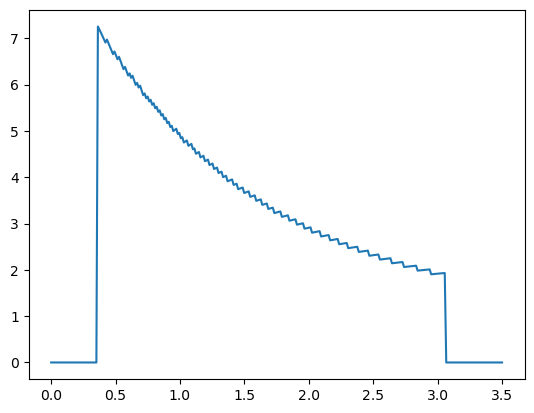

In [8]:
zi = np.linspace(0,3.5, 300)
Wi = np.array([W_f1_func(iz) for iz in zi])
plt.plot(zi,Wi)

In [13]:
if params_APS['field_2'].lower() == 'hi':
    params_APS['field_2_params'] = dcopy(params_hi_survey)
    params_APS['field_2_params'].update(hdata.nu_bins_vector(numin_ =params_APS['field_2_params']['freq_min'], 
                                        numax_ =params_APS['field_2_params']['freq_max'], 
                                        nbands_=params_APS['field_2_params']['nchannels'])
                                       )
    params_APS['field_2_params']['z'] = dcopy(np.flip(params_APS['field_2_params']['z']))    
    W_f2_func  = lambda x: cxft.kernel_hi(camb_params=pars, camb_results=results, 
                                     z=x, zrange=params_APS['field_2_params']['z'], 
                                     config_dict=params_APS['field_2_params'] , replace_inf2nan=True)    
    params_APS['field_2_params']['header'] = "[1] l, [>2] {}-{} Cl [multipoles, redshift/frequency bins]".format(params_APS['field_2'].upper(), params_APS['field_2'].upper())    
    del params_APS['field_2_params']['min'], params_APS['field_2_params']['max']    
    print('Field 2: HI')    
    del params_hi_survey
    #
elif params_APS['field_2'].lower() in ['cmbwl', 'wlcmb', 'convergence', 'cmb', 'kcmb', 'cmbk']:    
    params_APS['field_2_params'] = dcopy(params_cmbwl_survey)    
    params_APS['field_2_params']['z_min'] = 0
    params_APS['field_2_params']['z_max'] = cxft.chi_vec(results)['z_star']    
    W_f2_func  = cxft.kernel_cmb_interp(camb_params=pars, camb_results=results)
    params_APS['field_2_params']['header'] = "[1] l, [2] {f2}-{f2} Cl [multipoles, redshift/frequency bin] --survey: CMB".format(f2=params_APS['field_2'].upper())    
    print('Field 2: CMB WL')        
    del params_cmbwl_survey
    #
elif params_APS['field_2'].lower() in ['lensing','lens', 'shear']:       
    params_APS['field_2_params'] = dcopy(params_shear_survey)  
    params_APS['field_2_params'].update(cxft.survey_parameters(survey_name = params_APS['field_2_params']['survey'], 
                                        data_release= params_APS['field_2_params']['dataset'],
                                        type_field='lensing',
                                        path_file=params_APS['field_2_params']['path_to_params_file'])
                                       )    
    W_f2_i = cxft.kernel_galaxy_lensing_i_dict(ibin=params_APS['field_2_params']['bin_to_use'],
                                              camb_params=pars, camb_results=results, binning=params_shear_survey['binning'], 
                                              pars=params_APS['field_2_params'], verbose=0)
    W_f2_func = lambda x: W_f2_i['W_interp'](x) if (x>=params_APS['field_2_params']['z_min'])*(x<=params_APS['field_2_params']['z_max']) else 0    
    params_APS['field_2_params']['header'] = "[1] l, [>2] {f1}-{f1} Cl [multipoles, redshift/frequency bin] --survey: {s} | --dataset: {d} | bin: {b}".format(f1=params_APS['field_2'].upper(),
                                                                                                                                                               s=params_APS['field_2_params']['survey'].upper(), 
                                                                                                                                                               d=params_APS['field_2_params']['dataset'].upper(),
                                                                                                                                                               b=params_APS['field_2_params']['bin_to_use']
                                                                                                                                                               )    
    print('Field 2: SHEAR')        
    del params_shear_survey

elif params_APS['field_2'].lower() in ['galaxy', 'density', 'dens', 'source', 'overdensity', 'count', 'counting']:           
    params_APS['field_2_params'] = dcopy(params_count_survey)  
    params_APS['field_2_params'].update(cxft.load_survey_parameters(survey_name = params_APS['field_2_params']['survey'], 
                                            data_release= params_APS['field_2_params']['dataset'], 
                                            type_field='density',
                                            path_file=params_APS['field_2_params']['path_to_params_file'])
                                       )       
    
    W_f2_i = cxft.kernel_galaxy_clustering_i_dict(camb_params=pars, camb_results=results, pars=params_APS['field_2_params'],
                                                  ibin = params_APS['field_2_params']['bin_to_use'],
                                                  include_mb = params_APS['field_2_params']['include_mb'] , growth_rate_f=None, 
                                                  bias_model = params_APS['field_2_params']['bias_model'], 
                                                  bias_value = params_APS['field_2_params']['bias_value'],
                                                  path_to_bias_file=params_APS['field_2_params']['path_to_bias_file'],
                                                  mb_model   = params_APS['field_2_params']['slope_s_model'], 
                                                  mb_alpha_value = params_APS['field_2_params']['slope_s_value'], 
                                                  path_to_mb_file=params_APS['field_2_params']['path_to_slope_s_file'], 
                                                  include_rsd=params_APS['field_2_params']['include_rsd'], 
                                                  mu_rsd=params_APS['field_2_params']['mu_rsd'], Np=500)        
    W_f2_func = lambda x: W_f2_i['W_interp'](x) if (x>=params_APS['field_2_params']['z_min'])*(x<=params_APS['field_2_params']['z_max']) else 0    
    params_APS['field_2_params']['header'] = "[1] l, [>2] {f1}-{f1} Cl [multipoles, redshift/frequency bin] --survey: {s} | --dataset: {d} | bin: {b}".format(f1=params_APS['field_2'].upper(),
                                                                                                                                                               s=params_APS['field_2_params']['survey'].upper(), 
                                                                                                                                                               d=params_APS['field_2_params']['dataset'].upper(),
                                                                                                                                                               b=params_APS['field_2_params']['bin_to_use']
                                                                                                                                                               )    
    
    print('Field 2: COUNT')
    del params_count_survey
else:
    raise NameError('No Field named {}'.format( params_APS['field_2']))  

Field 2: COUNT


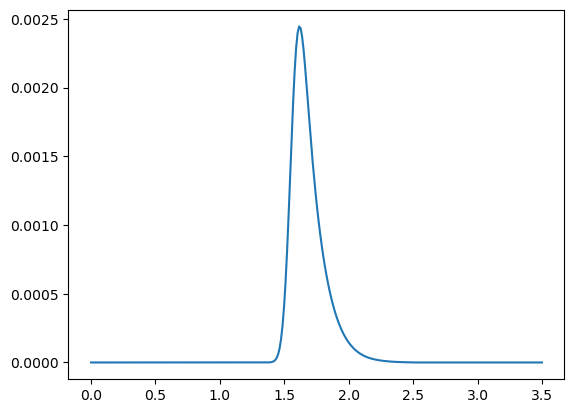

In [8]:
zi = np.linspace(0,3.5, 300)
Wi = np.array([W_f2_func(iz) for iz in zi])
plt.plot(zi,Wi)

In [ ]:
#####################################################################################################
#####################################################################################################
if params_general['verbose']:
    print('\n------------------------------------------')
    print('Starting to produce Angular Power Spectrum')
    print('------------------------------------------\n')

plot_together_f1 = 0
plot_together_f2 = 0
plot_together_fx = 0

if params_APS['generate_cl_field_1']:
    if params_general['verbose']: print('Generating {} Ang Power Spectrum...'.format(params_APS['field_1'].upper()))
    # Mandatory f1=HI -- the same estructure can be use to gamma
    Cl_f1 = np.array([ cxft.angular_power_spectrum_ij(camb_params=pars, camb_results=results, 
                                                      Pk_camb_interp=pk_interp,
                                                      W_f1_i=W_f1_func, W_f2_j=W_f1_func, 
                                                      l=params_APS['l'], 
                                                      z_min=params_APS['field_1_params']['z'][i], 
                                                      z_max=params_APS['field_1_params']['z'][i+1])['cl'] 
                        for i in range(params_APS['field_1_params']['z'].size-1) ])   
    ###
    ind = np.where([(Cl_f1<params_general['threshold'])*(Cl_f1>-params_general['threshold'])])[0]
    if len(ind): Cl_f1[ind]=0
    ###
    if params_general['verbose']: print('Generated.\nSaving...')
    import creating_dir
    creating_dir.verification_dir(params_APS['pathout'].split('/')[-1], "/".join(( params_APS['pathout'].split('/')[:-1] )))
    #creating_dir.verification_dir("auxiliary_data",params_APS['pathout'])
    pathname = cxft.savedata(l_ = params_APS['l'], 
                             Cl_= np.asmatrix(Cl_f1), filename='{}_cl'.format(params_APS['field_1'].upper()), 
                             prefix = params_APS['prefix'] , suffix=params_APS['suffix'], 
                             path   = params_APS['pathout'], header=params_APS['field_1_params']['header'])        
    if params_general['verbose']: print('Saved at {}'.format(pathname))
    if params_APS['save_clplot_field1']:
        if params_general['verbose']: 
            print('Saving plot...')
        clf1_dict = cxft.cls_from_matrix2dict(np.vstack((params_APS['l'],Cl_f1)) )
        pathname  = cxft.save_plots(params_=params_APS, pathname_=pathname, clf_dict=clf1_dict, field='shear')
        if params_general['verbose']: 
            print('Saved at {}'.format(pathname))
    if not params_APS['save_cls_together']: 
        del clf1_dict
    else: 
        plot_together_f1 = 1
    print('\n')

if params_APS['generate_cl_field_2']:
    if params_general['verbose']: print('Generating {} Ang Power Spectrum...'.format(params_APS['field_2'].upper()))
    Cl_f2 = cxft.angular_power_spectrum_ij(camb_params=pars, camb_results=results, 
                                           Pk_camb_interp=pk_interp,
                                           W_f1_i=W_f2_func, W_f2_j=W_f2_func, 
                                           l=params_APS['l'], 
                                           z_min=params_APS['field_2_params']['z_min'], 
                                           z_max=params_APS['field_2_params']['z_max'])['cl'] 
    ###
    ind = np.where([(Cl_f2<params_general['threshold'])*(Cl_f2>-params_general['threshold'])])[0]
    if len(ind): Cl_f2[ind]=0    
    ###
    if params_general['verbose']: print('Generated.\nSaving...')
    import creating_dir
    creating_dir.verification_dir(params_APS['pathout'].split('/')[-1], "/".join(( params_APS['pathout'].split('/')[:-1] )))
    pathname = cxft.savedata(l_ = params_APS['l'], 
                             Cl_= np.asmatrix(Cl_f2), filename='{}_cl'.format(params_APS['field_2'].upper()), 
                             prefix = params_APS['prefix'] , suffix=params_APS['suffix'], 
                             path   = params_APS['pathout'], header=params_APS['field_2_params']['header'])  
    if params_general['verbose']: print('Saved at {}'.format(pathname))
    if params_APS['save_clplot_field2']:
        if params_general['verbose']: 
            print('Saving plot...')
        clf2_dict = cxft.cls_from_matrix2dict(np.vstack((params_APS['l'],Cl_f2)) )
        pathname = cxft.save_plots(params_=params_APS, pathname_=pathname, clf_dict=clf2_dict, field='hi')
        if params_general['verbose']: 
            print('Saved at {}'.format(pathname))
    if not params_APS['save_cls_together']: 
        del clf2_dict
    else: 
        plot_together_f2 = 1
    print('\n') 


if params_APS['generate_cl_cross']:
    if params_general['verbose']: print('Generating {}WLx{} Ang Power Spectrum...'.format(params_APS['field_1'].upper(), params_APS['field_2'].upper()))
    Cl_f1f2 = np.array([ cxft.angular_power_spectrum_ij(camb_params=pars, camb_results=results, 
                                                        Pk_camb_interp=pk_interp,
                                                        W_f1_i=W_f1_func, W_f2_j=W_f2_func, 
                                                        l=params_APS['l'], 
                                                        z_min=params_APS['field_1_params']['z'][i], 
                                                        z_max=params_APS['field_1_params']['z'][i+1])['cl'] 
                        for i in range(params_APS['field_1_params']['z'].size-1) ])    
    ###
    ind = np.where([(Cl_f1f2<params_general['threshold'])*(Cl_f1f2>-params_general['threshold'])])[0]
    if len(ind): 
        Cl_f1f2[ind]=0
        print(len(ind))
    ###
    if params_general['verbose']: print('Generated.\nSaving...')
    import creating_dir
    creating_dir.verification_dir(params_APS['pathout'].split('/')[-1], "/".join(( params_APS['pathout'].split('/')[:-1] )))
    #creating_dir.verification_dir("auxiliary_data",params_APS['pathout'])
    pathname = cxft.savedata(l_ = params_APS['l'], 
                             Cl_= np.asmatrix(Cl_f1f2), filename='{}x{}_cl'.format(params_APS['field_1'].upper(), params_APS['field_2'].upper()), 
                             prefix = params_APS['prefix'] , suffix=params_APS['suffix'], 
                             path   = params_APS['pathout'], 
                             header =  "[1] l, [>2] {}-{} Cl [multipoles, redshift/frequency bins]".format(params_APS['field_1'].upper(), params_APS['field_2'].upper())
                            )      
    if params_general['verbose']: print('Saved at {}'.format(pathname))
    if params_APS['save_clplot_cross']:
        if params_general['verbose']: 
            print('Saving plot...')
        clcx_dict = cxft.cls_from_matrix2dict(np.vstack((params_APS['l'],Cl_f1f2)) )
        pathname  = cxft.save_plots(params_=params_APS, pathname_=pathname, clf_dict=clcx_dict, field='cross')
        if params_general['verbose']: 
            print('Saved at {}'.format(pathname))
    if not params_APS['save_cls_together']: 
        del clcx_dict
    else: 
        plot_together_fx = 1        
    #del zmin, zmax, dCross_dz, cross, Cross_bins,Cross, Wkappa, Whi  
    print('\n')
	
if params_general['verbose']:
    print('------------------------------------------')
    print('END')
    print('------------------------------------------\n')